In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import kurtosis, skew
import os

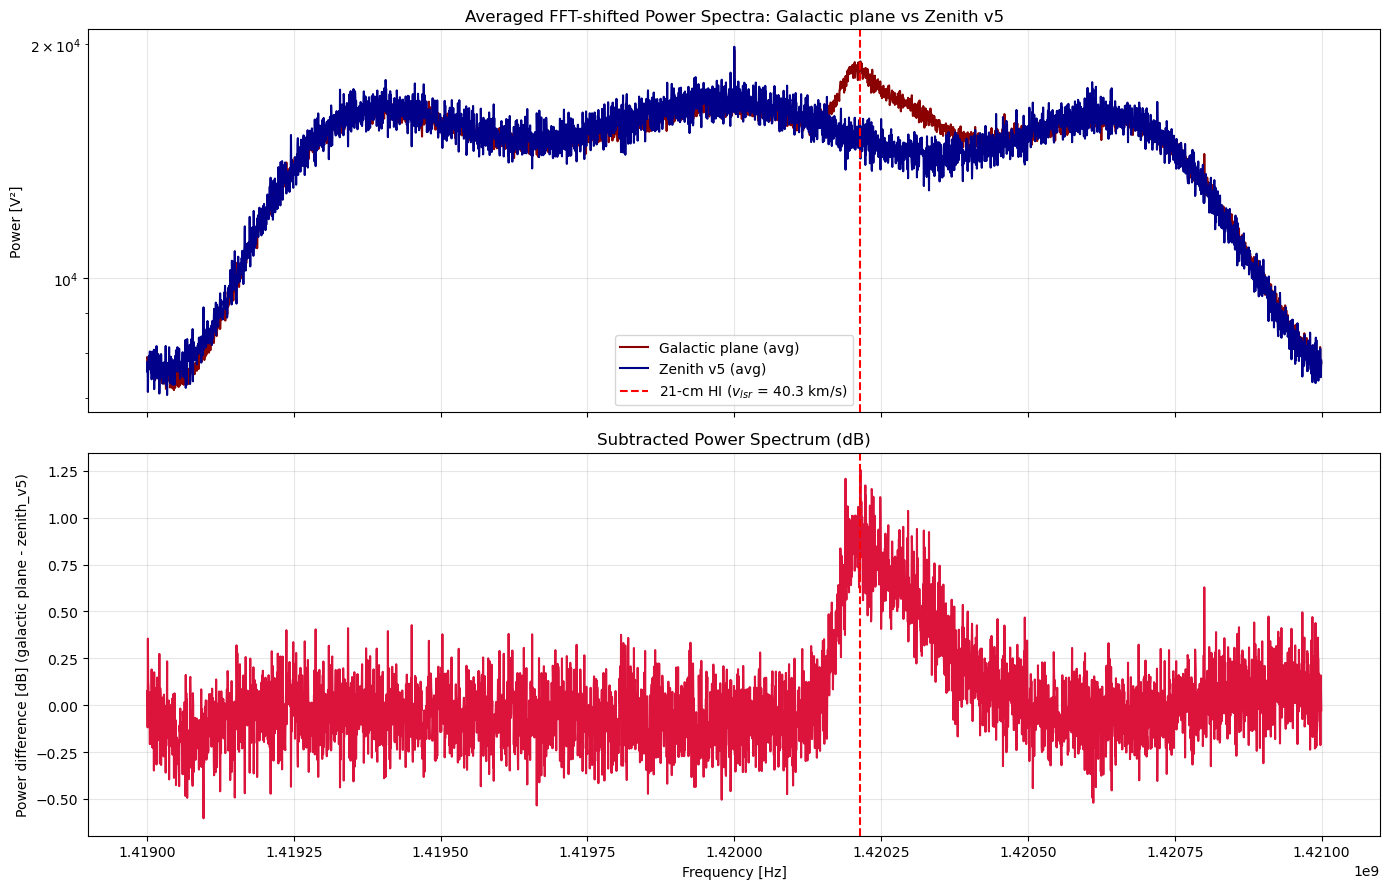

Max dB difference: 1.254 dB at 1.420e+09 Hz
Min dB difference: -0.604 dB at 1.419e+09 Hz
HI line frequency (adjusted): 1.420215e+09 Hz
Doppler shift: 40.32 km/s
Saved figure: Lab 2/figures/galactic_plane_minus_zenith_v5_difference.png


In [2]:
# Subtracted averaged fftshifted power spectrum: galactic plane - zenith v5
# Loads `bighorn_galactic_plane.npz` and `bighorn_zenith_v5.npz`, averages fftshifted power per block, subtracts and plots
# Includes Doppler shift for HI line based on velocity

# === Doppler/redshift parameters ===
f_HI_rest = 1420.40575177e6  # Rest frequency of 21 cm HI line [Hz]
c = 3e8  # Speed of light [m/s]
v_lsr = 40.32  # Line-of-sight velocity relative to LSR [km/s]. Positive = receding, Negative = approaching

# Convert velocity to frequency shift (Doppler formula, non-relativistic approximation valid for v << c)
# For small velocities: Δf/f ≈ -v/c (negative because receding increases wavelength)
f_HI = f_HI_rest * (1.0 - v_lsr * 1000 / c)  # Convert km/s to m/s

fn_gal = "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/bighorn_galactic_plane.npz"
fn_zen_v5 = "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/bighorn_zenith_v5.npz"

data_gal = np.load(fn_gal)
data_zen_v5 = np.load(fn_zen_v5)

samples_gal = data_gal["samples"]
samples_zen_v5 = data_zen_v5["samples"]

fs_local = 2e6
f_offset = 1420e6

# helper to compute averaged fftshifted power
def avg_shifted_power(samples_arr, fs):
    num_blocks = samples_arr.shape[0]
    N = samples_arr.shape[1]
    acc = np.zeros(N, dtype=float)
    for i in range(num_blocks):
        blk = samples_arr[i]
        x_blk = blk[:,0] + 1j*blk[:,1]
        X_blk = np.fft.fft(x_blk)
        Xs = np.fft.fftshift(X_blk)
        P = (np.abs(Xs)**2) / N
        acc += P
    Pavg = acc / num_blocks
    freqs = np.fft.fftfreq(N, 1/fs)
    freqs_shift = np.fft.fftshift(freqs) + f_offset
    return freqs_shift, Pavg

freq_gal, Pgal = avg_shifted_power(samples_gal, fs_local)
freq_zen_v5, Pzen_v5 = avg_shifted_power(samples_zen_v5, fs_local)

# align frequency axes if needed
if len(freq_gal) != len(freq_zen_v5) or not np.allclose(freq_gal, freq_zen_v5):
    fmin = max(freq_gal.min(), freq_zen_v5.min())
    fmax = min(freq_gal.max(), freq_zen_v5.max())
    npts = min(len(freq_gal), len(freq_zen_v5))
    f_common = np.linspace(fmin, fmax, npts)
    Pgal_i = np.interp(f_common, freq_gal, Pgal)
    Pzen_v5_i = np.interp(f_common, freq_zen_v5, Pzen_v5)
    f_plot = f_common
    Pgal_plot = Pgal_i
    Pzen_v5_plot = Pzen_v5_i
else:
    f_plot = freq_gal
    Pgal_plot = Pgal
    Pzen_v5_plot = Pzen_v5

# subtraction
Pdiff = Pgal_plot - Pzen_v5_plot
Pdiff_db = 10*np.log10(Pgal_plot + 1e-20) - 10*np.log10(Pzen_v5_plot + 1e-20)

# Plot
fig, (ax1, ax2) = plt.subplots(2,1,figsize = (14,9), sharex = True)
ax1.plot(f_plot, Pgal_plot, label = 'Galactic plane (avg)', color = 'darkred')
ax1.plot(f_plot, Pzen_v5_plot, label = 'Zenith v5 (avg)', color = 'darkblue')
ax1.set_yscale('log')
ax1.set_ylabel('Power [V²]')
ax1.set_title('Averaged FFT-shifted Power Spectra: Galactic plane vs Zenith v5')
ax1.grid(True, alpha = 0.3)
ax1.axvline(f_HI, color = 'red', linestyle = '--', label = f'21-cm HI ($v_{{lsr}}$ = {v_lsr:.1f} km/s)')
ax1.legend()

ax2.plot(f_plot, Pdiff_db, color='crimson')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel('Power difference [dB] (galactic plane - zenith_v5)')
ax2.set_title('Subtracted Power Spectrum (dB)')
ax2.grid(True, alpha = 0.3)
ax2.axvline(f_HI, color = 'red', linestyle = '--')

plt.tight_layout()

os.makedirs('Lab 2/figures', exist_ok = True)
outfn = 'Lab 2/figures/galactic_plane_minus_zenith_v5_difference.png'
plt.savefig(outfn, dpi = 300, bbox_inches = 'tight')
plt.show()

# report peaks
imax = np.argmax(Pdiff_db)
imin = np.argmin(Pdiff_db)
print(f"Max dB difference: {Pdiff_db[imax]:.3f} dB at {f_plot[imax]:.3e} Hz")
print(f"Min dB difference: {Pdiff_db[imin]:.3f} dB at {f_plot[imin]:.3e} Hz")
print(f"HI line frequency (adjusted): {f_HI:.6e} Hz")
print(f"Doppler shift: {v_lsr:.2f} km/s")
print(f"Saved figure: {outfn}")

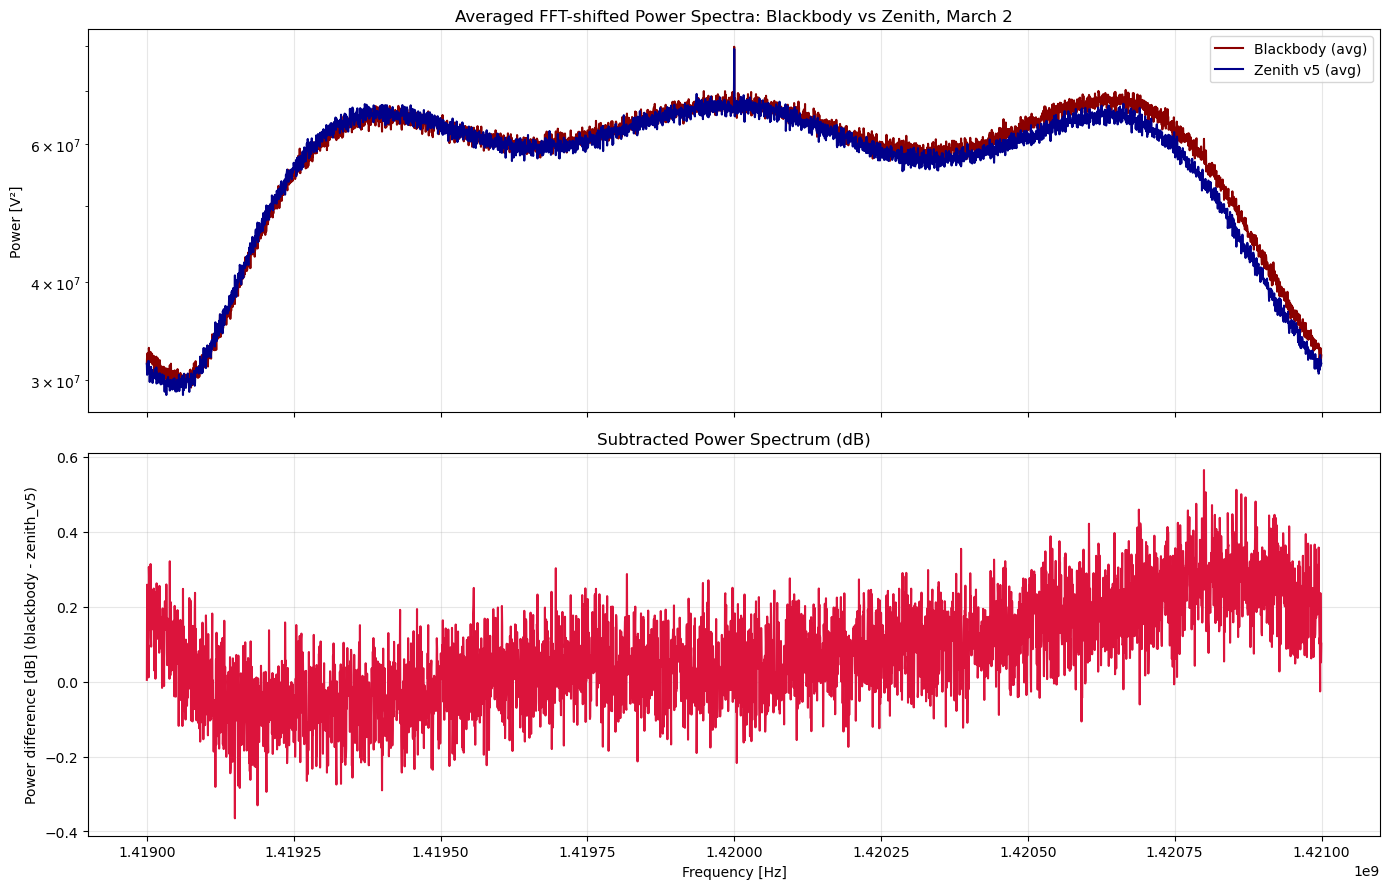

Max dB difference: 0.565 dB at 1.421e+09 Hz
Min dB difference: -0.365 dB at 1.419e+09 Hz
HI line frequency (adjusted): 1.420215e+09 Hz
Doppler shift: 40.32 km/s
Saved figure: Lab 2/figures/blackbody_minus_zenith_v5_difference.png


In [3]:
# Subtracted averaged fftshifted power spectrum: galactic plane - zenith v5
# Loads `bighorn_galactic_plane.npz` and `bighorn_zenith_v5.npz`, averages fftshifted power per block, subtracts and plots
# Includes Doppler shift for HI line based on velocity

# === Doppler/redshift parameters ===
f_HI_rest = 1420.40575177e6  # Rest frequency of 21 cm HI line [Hz]
c = 3e8  # Speed of light [m/s]
v_lsr = 40.32  # Line-of-sight velocity relative to LSR [km/s]. Positive = receding, Negative = approaching

# Convert velocity to frequency shift (Doppler formula, non-relativistic approximation valid for v << c)
# For small velocities: Δf/f ≈ -v/c (negative because receding increases wavelength)
f_HI = f_HI_rest * (1.0 - v_lsr * 1000 / c)  # Convert km/s to m/s

fn_body = "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/3-2 Data/bighorn_blackbody_0302 (1).npz"
fn_zen_v5 = "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/3-2 Data/bighorn_zenith_0302.npz"

data_body = np.load(fn_body)
data_zen_v5 = np.load(fn_zen_v5)

samples_body = data_body["samples"]
samples_zen_v5 = data_zen_v5["samples"]

fs_local = 2e6
f_offset = 1420e6

# helper to compute averaged fftshifted power
def avg_shifted_power(samples_arr, fs):
    num_blocks = samples_arr.shape[0]
    N = samples_arr.shape[1]
    acc = np.zeros(N, dtype=float)
    for i in range(num_blocks):
        blk = samples_arr[i]
        x_blk = blk[:,0] + 1j*blk[:,1]
        X_blk = np.fft.fft(x_blk)
        Xs = np.fft.fftshift(X_blk)
        P = (np.abs(Xs)**2) #/ N
        acc += P
    Pavg = acc / num_blocks
    freqs = np.fft.fftfreq(N, 1/fs)
    freqs_shift = np.fft.fftshift(freqs) + f_offset
    return freqs_shift, Pavg

freq_body, Pbody = avg_shifted_power(samples_body, fs_local)
freq_zen_v5, Pzen_v5 = avg_shifted_power(samples_zen_v5, fs_local)

# align frequency axes if needed
if len(freq_body) != len(freq_zen_v5) or not np.allclose(freq_body, freq_zen_v5):
    fmin = max(freq_body.min(), freq_zen_v5.min())
    fmax = min(freq_body.max(), freq_zen_v5.max())
    npts = min(len(freq_body), len(freq_zen_v5))
    f_common = np.linspace(fmin, fmax, npts)
    Pbody_i = np.interp(f_common, freq_body, Pbody)
    Pzen_v5_i = np.interp(f_common, freq_zen_v5, Pzen_v5)
    f_plot = f_common
    Pbody_plot = Pbody_i
    Pzen_v5_plot = Pzen_v5_i
else:
    f_plot = freq_body
    Pbody_plot = Pbody
    Pzen_v5_plot = Pzen_v5

# subtraction
Pdiff = Pbody_plot - Pzen_v5_plot
Pdiff_db = 10*np.log10(Pbody_plot + 1e-20) - 10*np.log10(Pzen_v5_plot + 1e-20)

# Plot
fig, (ax1, ax2) = plt.subplots(2,1,figsize = (14,9), sharex = True)
ax1.plot(f_plot, Pbody_plot, label = 'Blackbody (avg)', color = 'darkred')
ax1.plot(f_plot, Pzen_v5_plot, label = 'Zenith v5 (avg)', color = 'darkblue')
ax1.set_yscale('log')
ax1.set_ylabel('Power [V²]')
ax1.set_title('Averaged FFT-shifted Power Spectra: Blackbody vs Zenith, March 2')
ax1.grid(True, alpha = 0.3)
#ax1.axvline(f_HI, color = 'red', linestyle = '--', label = f'21-cm HI ($v_{{lsr}}$ = {v_lsr:.1f} km/s)')
ax1.legend()

ax2.plot(f_plot, Pdiff_db, color='crimson')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel('Power difference [dB] (blackbody - zenith_v5)')
ax2.set_title('Subtracted Power Spectrum (dB)')
ax2.grid(True, alpha = 0.3)
#ax2.axvline(f_HI, color = 'red', linestyle = '--')

plt.tight_layout()

os.makedirs('Lab 2/figures', exist_ok = True)
outfn = 'Lab 2/figures/blackbody_minus_zenith_v5_difference.png'
plt.savefig(outfn, dpi = 300, bbox_inches = 'tight')
plt.show()

# report peaks
imax = np.argmax(Pdiff_db)
imin = np.argmin(Pdiff_db)
print(f"Max dB difference: {Pdiff_db[imax]:.3f} dB at {f_plot[imax]:.3e} Hz")
print(f"Min dB difference: {Pdiff_db[imin]:.3f} dB at {f_plot[imin]:.3e} Hz")
print(f"HI line frequency (adjusted): {f_HI:.6e} Hz")
print(f"Doppler shift: {v_lsr:.2f} km/s")
print(f"Saved figure: {outfn}")

In [4]:
from astropy.coordinates import Galactic, FK5
from astropy.time import Time
import astropy.units as u

# Convert Galactic to Equatorial (J2000)
target_gal = Galactic(l=120*u.deg, b=0*u.deg)
target_eq = target_gal.transform_to(FK5(equinox='J2000'))
print(f"RA = {target_eq.ra.to_string(unit=u.hour, sep=':')}")
print(f"Dec = {target_eq.dec.to_string(unit=u.deg, sep=':')}")

RA = 0:25:48.20368848
Dec = 62:43:32.62312109


In [ ]:
import numpy as np
from astropy.time import Time
from astropy.coordinates import EarthLocation
import astropy.units as u

# Load your data
data = np.load('C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/3-2 data/bighorn_120_0_calib.npz', allow_pickle=True)
jd = data['jd'].item()

# Set Campbell Hall location
nch = EarthLocation(lat=37.8732*u.deg, lon=-122.2573*u.deg, height=200*u.m)

# Create Time object and get LST
t = Time(jd, format='jd', location=nch)
lst = t.sidereal_time('apparent').hour

print(f"JD: {jd}")
print(f"LST: {lst} hours")

KeyError: 'jd is not a file in the archive'

In [8]:
import numpy as np

# Load the data
data = np.load('C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/3-2 data/bighorn_120_0_calib.npz', allow_pickle=True)

# List all the keys in the archive
print("Keys in the archive:", data.files)

# Try to access the JD key if it exists under a different name
# Common alternatives: 'JD', 'julian_date', 'time', etc.

import numpy as np

data = np.load('C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/3-2 data/bighorn_120_0_calib.npz', allow_pickle=True)

lst_before = data['lst_before'].item()
lst_after = data['lst_after'].item()
jd_before = data['jd_before'].item()
jd_after = data['jd_after'].item()

print(f"LST before: {lst_before} hours")
print(f"LST after: {lst_after} hours")
print(f"JD before: {jd_before}")
print(f"JD after: {jd_after}")

Keys in the archive: ['samples', 'gain', 'jd_before', 'jd_after', 'utc_before', 'utc_after', 'utc_unix_before', 'utc_unix_after', 'local_before', 'local_after', 'lst_before', 'lst_after', 'coords_altaz', 'coords_lb', 'coords_nch', 'center_freq', 'sample_rate']
LST before: 0.5267165739618073 hours
LST after: 0.5361890994804893 hours
JD before: 2461101.47959441
JD after: 2461101.481097895


In [11]:
import numpy as np

files = [
    'bighorn_120_0_leftside.npz',
    'bighorn_120_0_rightside.npz', 
    'bighorn_120_0_calib.npz'
]

for file in files:
    data = np.load(f'C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/3-2 data/{file}', allow_pickle=True)
    lst_before = data['lst_before'].item()
    lst_after = data['lst_after'].item()
    jd_before = data['jd_before'].item()
    
    print(f"{file}:")
    print(f"  LST ≈ {(lst_before + lst_after)/2:.3f} hours")
    print(f"  JD ≈ {jd_before:.5f}")
    print()

bighorn_120_0_leftside.npz:
  LST ≈ 0.517 hours
  JD ≈ 2461101.47729

bighorn_120_0_rightside.npz:
  LST ≈ 0.502 hours
  JD ≈ 2461101.47498

bighorn_120_0_calib.npz:
  LST ≈ 0.531 hours
  JD ≈ 2461101.47959



In [13]:
import numpy as np

files = [
    'bighorn_120_0_leftside.npz',
    'bighorn_120_0_rightside.npz', 
    'bighorn_120_0_calib.npz'
]

for file in files:
    data = np.load(f'C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/3-2 data/{file}', allow_pickle=True)
    
    center_freq = data['center_freq'].item()
    sample_rate = data['sample_rate'].item()
    
    samples = data['samples']
    
    print(f"{file}:")
    print(f"  Center frequency: {center_freq/1e6:.1f} MHz")
    print(f"  Sample rate: {sample_rate/1e6:.1f} MHz")
    print(f"  Samples type: {type(samples)}")
    print(f"  Samples shape: {samples.shape if hasattr(samples, 'shape') else 'no shape attribute'}")
    print(f"  Samples length: {len(samples) if hasattr(samples, '__len__') else 'unknown'}")
    print()

bighorn_120_0_leftside.npz:
  Center frequency: 1420.8 MHz
  Sample rate: 3.2 MHz
  Samples type: <class 'numpy.ndarray'>
  Samples shape: (100000, 4096, 2)
  Samples length: 100000

bighorn_120_0_rightside.npz:
  Center frequency: 1420.0 MHz
  Sample rate: 3.2 MHz
  Samples type: <class 'numpy.ndarray'>
  Samples shape: (100000, 4096, 2)
  Samples length: 100000

bighorn_120_0_calib.npz:
  Center frequency: 1418.0 MHz
  Sample rate: 3.2 MHz
  Samples type: <class 'numpy.ndarray'>
  Samples shape: (100000, 4096, 2)
  Samples length: 100000



In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Load your three files
on_data = np.load('C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/3-2 data/bighorn_120_0_leftside.npz', allow_pickle=True)
off_data = np.load('C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/3-2 data/bighorn_120_0_rightside.npz', allow_pickle=True)
cal_data = np.load('C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/3-2 data/bighorn_120_0_calib.npz', allow_pickle=True)

# Extract samples
on_samples = on_data['samples']  # shape: (100000, 4096, 2)
off_samples = off_data['samples']
cal_samples = cal_data['samples']

print(f"On samples shape: {on_samples.shape}")
print(f"Off samples shape: {off_samples.shape}")
print(f"Cal samples shape: {cal_samples.shape}")

# Check one block to see what the data looks like
print(f"\nFirst block first few samples: {on_samples[0, :5, 0]}")
print(f"Data type: {on_samples.dtype}")

On samples shape: (100000, 4096, 2)
Off samples shape: (100000, 4096, 2)
Cal samples shape: (100000, 4096, 2)

First block first few samples: [-2 -1 -1 -1  0]
Data type: int8


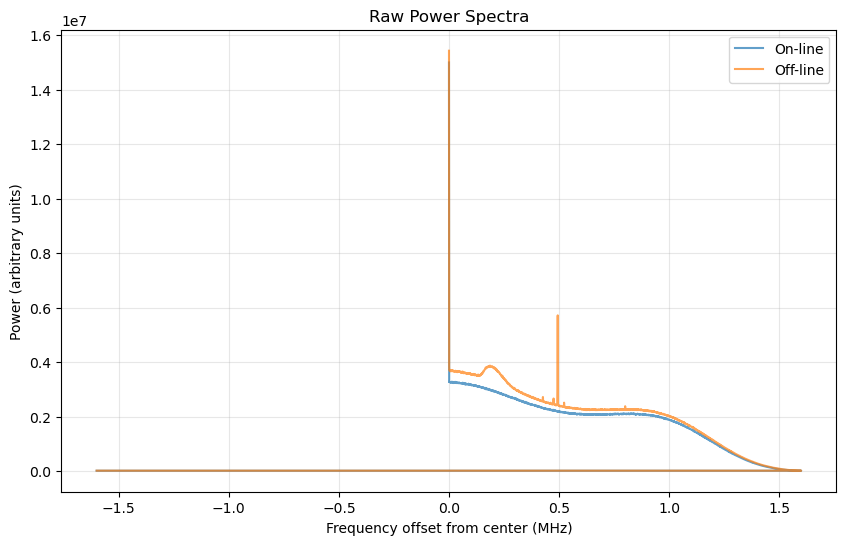

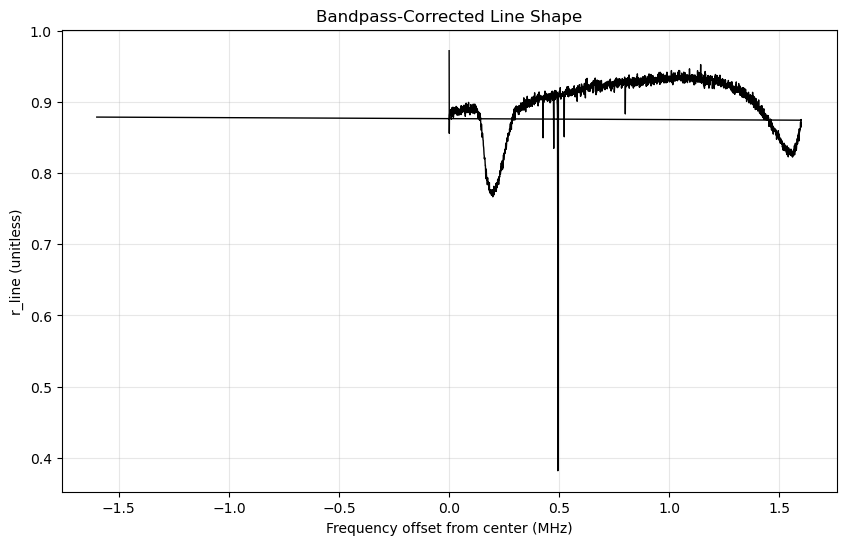

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Function to convert int8 I/Q to complex and compute power spectrum
def compute_power_spectrum(samples, sample_rate=3.2e6):
    """
    samples: array of shape (nblocks, 4096, 2) with int8 I/Q data
    returns: average power spectrum (linear units)
    """
    nblocks = samples.shape[0]
    nfft = samples.shape[1]
    
    # Initialize array for accumulated power
    power_sum = np.zeros(nfft//2 + 1)
    
    for i in range(nblocks):
        # Convert I/Q to complex
        complex_data = samples[i, :, 0] + 1j * samples[i, :, 1]
        
        # Compute FFT
        fft_data = np.fft.fft(complex_data)
        
        # Power spectrum (positive frequencies only)
        power = np.abs(fft_data[:nfft//2 + 1])**2
        
        # Accumulate
        power_sum += power
    
    # Average
    power_avg = power_sum / nblocks
    
    # Create frequency axis
    freqs = np.fft.fftfreq(nfft, 1/sample_rate)[:nfft//2 + 1] / 1e6  # MHz
    
    return freqs, power_avg

# Compute spectra for on and off
freqs, on_power = compute_power_spectrum(on_samples)
_, off_power = compute_power_spectrum(off_samples)

# Plot raw spectra
plt.figure(figsize=(10, 6))
plt.plot(freqs, on_power, label='On-line', alpha=0.7)
plt.plot(freqs, off_power, label='Off-line', alpha=0.7)
plt.xlabel('Frequency offset from center (MHz)')
plt.ylabel('Power (arbitrary units)')
plt.title('Raw Power Spectra')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Compute and plot ratio (bandpass-corrected line shape)
r_line = on_power / off_power

plt.figure(figsize=(10, 6))
plt.plot(freqs, r_line, 'k-', linewidth=1)
plt.xlabel('Frequency offset from center (MHz)')
plt.ylabel('r_line (unitless)')
plt.title('Bandpass-Corrected Line Shape')
plt.grid(True, alpha=0.3)
plt.show()

On-line center frequency: 1420.81 MHz
Off-line center frequency: 1420.0 MHz


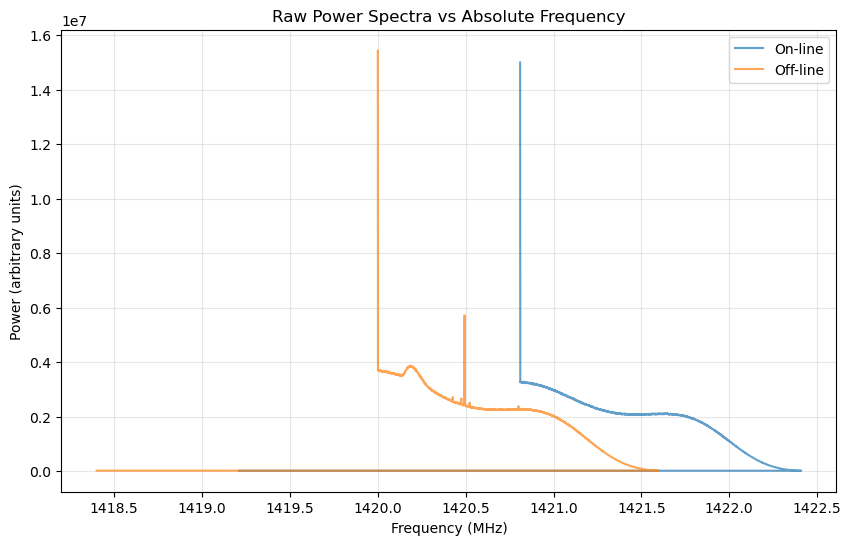

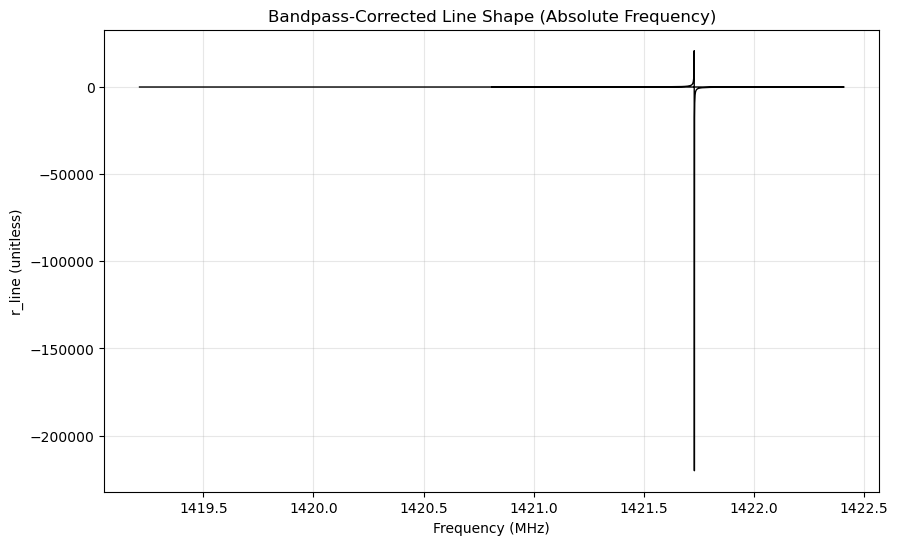

In [17]:
# Get center frequencies
f_center_on = on_data['center_freq'].item() / 1e6  # MHz
f_center_off = off_data['center_freq'].item() / 1e6  # MHz

print(f"On-line center frequency: {f_center_on} MHz")
print(f"Off-line center frequency: {f_center_off} MHz")

# Create absolute frequency axes
freqs_on_abs = freqs + f_center_on
freqs_off_abs = freqs + f_center_off

# Plot vs absolute frequency
plt.figure(figsize=(10, 6))
plt.plot(freqs_on_abs, on_power, label='On-line', alpha=0.7)
plt.plot(freqs_off_abs, off_power, label='Off-line', alpha=0.7)
plt.xlabel('Frequency (MHz)')
plt.ylabel('Power (arbitrary units)')
plt.title('Raw Power Spectra vs Absolute Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# To properly compute ratio, we need to interpolate onto same frequency grid
from scipy import interpolate

# Interpolate off spectrum onto on-line frequency grid
interp_off = interpolate.interp1d(freqs_off_abs, off_power, 
                                  kind='linear', 
                                  bounds_error=False, 
                                  fill_value='extrapolate')
off_power_interp = interp_off(freqs_on_abs)

# Compute corrected ratio
r_line_corrected = on_power / off_power_interp

plt.figure(figsize=(10, 6))
plt.plot(freqs_on_abs, r_line_corrected, 'k-', linewidth=1)
plt.xlabel('Frequency (MHz)')
plt.ylabel('r_line (unitless)')
plt.title('Bandpass-Corrected Line Shape (Absolute Frequency)')
plt.grid(True, alpha=0.3)
plt.show()

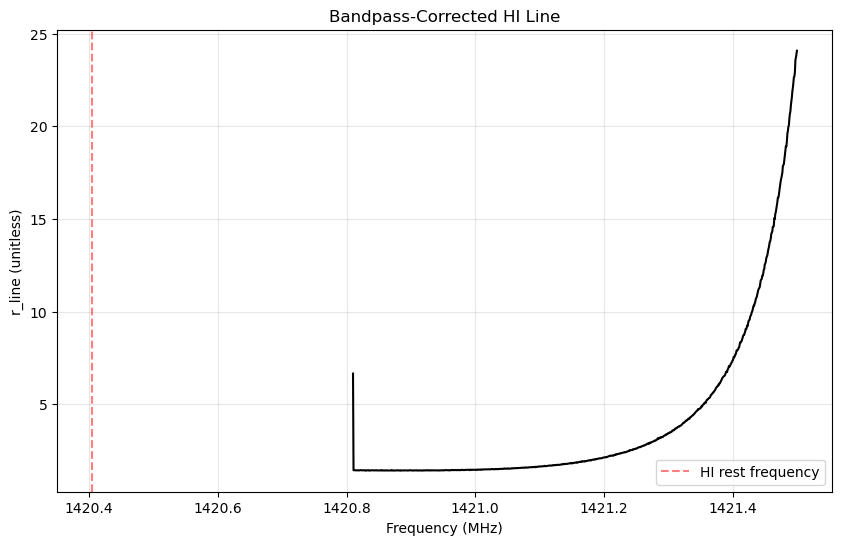

In [18]:
# Zoom in on the HI line region
mask = (freqs_on_abs > 1419.5) & (freqs_on_abs < 1421.5)

plt.figure(figsize=(10, 6))
plt.plot(freqs_on_abs[mask], r_line_corrected[mask], 'k-', linewidth=1.5)
plt.axvline(x=1420.405, color='r', linestyle='--', alpha=0.5, label='HI rest frequency')
plt.xlabel('Frequency (MHz)')
plt.ylabel('r_line (unitless)')
plt.title('Bandpass-Corrected HI Line')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Save for later
np.savez('corrected_spectrum.npz', 
         frequency=freqs_on_abs,
         r_line=r_line_corrected)

Computing on-line spectrum...
Computing off-line spectrum...
Computing calibration spectrum...

Center frequencies:
  On-line: 1420.81 MHz
  Off-line: 1420.0 MHz
  Cal: 1418.0 MHz

r_line stats:
  Min: -220116.630
  Max: 20818.210
  Mean: -104.463
  Std: 4921.666


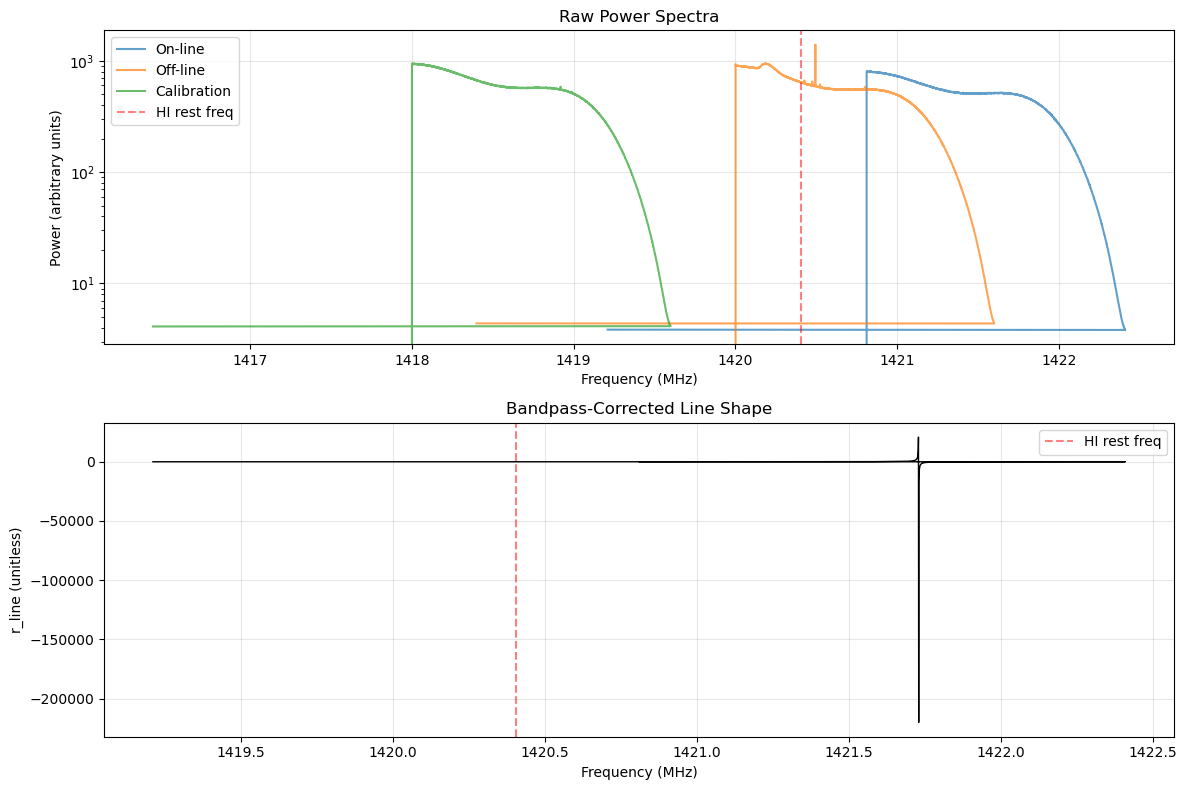

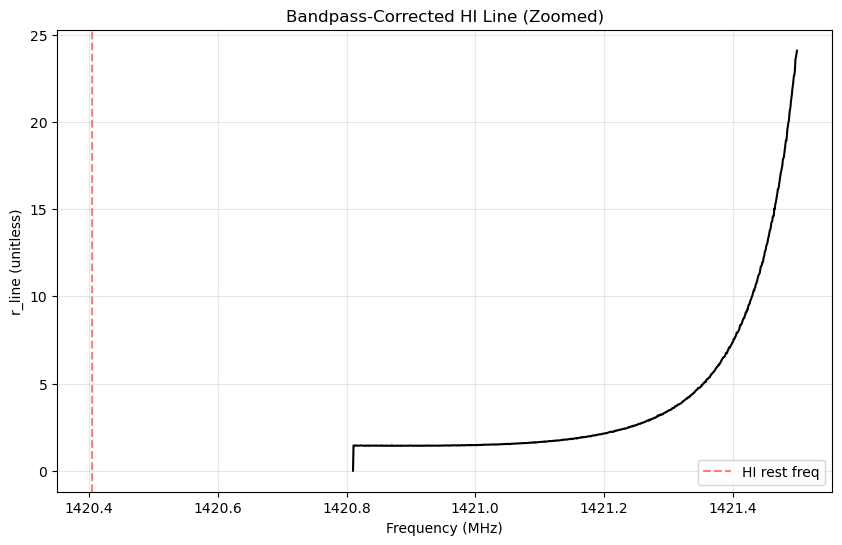

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate

# Load your three files
on_data = np.load('C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/3-2 data/bighorn_120_0_leftside.npz', allow_pickle=True)
off_data = np.load('C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/3-2 data/bighorn_120_0_rightside.npz', allow_pickle=True)
cal_data = np.load('C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/3-2 data/bighorn_120_0_calib.npz', allow_pickle=True)

# Extract samples
on_samples = on_data['samples']
off_samples = off_data['samples']
cal_samples = cal_data['samples']

def compute_power_spectrum_fixed(samples, sample_rate=3.2e6):
    """
    Compute power spectrum with DC removal and normalization
    """
    nblocks = samples.shape[0]
    nfft = samples.shape[1]
    
    power_sum = np.zeros(nfft//2 + 1)
    
    for i in range(nblocks):
        # Convert to complex and float
        complex_data = samples[i, :, 0].astype(float) + 1j * samples[i, :, 1].astype(float)
        
        # Remove DC offset (subtract mean)
        complex_data -= np.mean(complex_data)
        
        # Compute FFT
        fft_data = np.fft.fft(complex_data)
        
        # Power spectrum (positive frequencies only) - normalize by nfft
        power = np.abs(fft_data[:nfft//2 + 1])**2 / nfft
        
        power_sum += power
    
    power_avg = power_sum / nblocks
    
    # Frequency axis in MHz
    freqs = np.fft.fftfreq(nfft, 1/sample_rate)[:nfft//2 + 1] / 1e6
    
    return freqs, power_avg

# Compute spectra
print("Computing on-line spectrum...")
freqs, on_power = compute_power_spectrum_fixed(on_samples)
print("Computing off-line spectrum...")
_, off_power = compute_power_spectrum_fixed(off_samples)
print("Computing calibration spectrum...")
_, cal_power = compute_power_spectrum_fixed(cal_samples)

# Get center frequencies
f_center_on = on_data['center_freq'].item() / 1e6
f_center_off = off_data['center_freq'].item() / 1e6
f_center_cal = cal_data['center_freq'].item() / 1e6

print(f"\nCenter frequencies:")
print(f"  On-line: {f_center_on} MHz")
print(f"  Off-line: {f_center_off} MHz")
print(f"  Cal: {f_center_cal} MHz")

# Absolute frequencies
freqs_on_abs = freqs + f_center_on
freqs_off_abs = freqs + f_center_off
freqs_cal_abs = freqs + f_center_cal

# Interpolate off and cal onto on frequency grid
interp_off = interpolate.interp1d(freqs_off_abs, off_power, 
                                  kind='linear', 
                                  bounds_error=False, 
                                  fill_value='extrapolate')
off_power_interp = interp_off(freqs_on_abs)

interp_cal = interpolate.interp1d(freqs_cal_abs, cal_power,
                                  kind='linear',
                                  bounds_error=False,
                                  fill_value='extrapolate')
cal_power_interp = interp_cal(freqs_on_abs)

# Compute ratio
r_line = on_power / off_power_interp

# Check values
print(f"\nr_line stats:")
print(f"  Min: {np.min(r_line):.3f}")
print(f"  Max: {np.max(r_line):.3f}")
print(f"  Mean: {np.mean(r_line):.3f}")
print(f"  Std: {np.std(r_line):.3f}")

# Plot raw spectra
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(freqs_on_abs, on_power, label='On-line', alpha=0.7)
plt.plot(freqs_off_abs, off_power, label='Off-line', alpha=0.7)
plt.plot(freqs_cal_abs, cal_power, label='Calibration', alpha=0.7)
plt.axvline(x=1420.405, color='r', linestyle='--', alpha=0.5, label='HI rest freq')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Power (arbitrary units)')
plt.title('Raw Power Spectra')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Plot ratio
plt.subplot(2, 1, 2)
plt.plot(freqs_on_abs, r_line, 'k-', linewidth=1)
plt.axvline(x=1420.405, color='r', linestyle='--', alpha=0.5, label='HI rest freq')
plt.xlabel('Frequency (MHz)')
plt.ylabel('r_line (unitless)')
plt.title('Bandpass-Corrected Line Shape')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Zoom in on HI region
mask = (freqs_on_abs > 1419.5) & (freqs_on_abs < 1421.5)

plt.figure(figsize=(10, 6))
plt.plot(freqs_on_abs[mask], r_line[mask], 'k-', linewidth=1.5)
plt.axvline(x=1420.405, color='r', linestyle='--', alpha=0.5, label='HI rest freq')
plt.xlabel('Frequency (MHz)')
plt.ylabel('r_line (unitless)')
plt.title('Bandpass-Corrected HI Line (Zoomed)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Save for later
np.savez('my_corrected_spectrum.npz', 
         frequency=freqs_on_abs,
         r_line=r_line,
         on_power=on_power,
         off_power=off_power,
         cal_power=cal_power)

In [21]:
# Quick diagnostic
print("Data shape and type:")
print(f"on_samples shape: {on_samples.shape}, dtype: {on_samples.dtype}")
print(f"First block stats:")
first_block = on_samples[0, :, 0].astype(float) + 1j*on_samples[0, :, 1].astype(float)
print(f"  Mean: {np.mean(first_block):.2f}")
print(f"  Std: {np.std(first_block):.2f}")
print(f"  Min: {np.min(first_block):.2f}")
print(f"  Max: {np.max(first_block):.2f}")

# Check a small sample of the power spectra we computed
print(f"\nFirst 10 values of on_power:")
print(on_power[:10])
print(f"\nFirst 10 values of off_power:")
print(off_power[:10])

Data shape and type:
on_samples shape: (100000, 4096, 2), dtype: int8
First block stats:
  Mean: -0.66-0.35j
  Std: 20.78
  Min: -59.00+18.00j
  Max: 57.00-1.00j

First 10 values of on_power:
[  0.         798.30091891 802.09718462 798.10595741 800.27457637
 798.18207534 798.61648871 797.21042574 794.43207306 796.95329151]

First 10 values of off_power:
[  0.         932.6270837  910.03657843 903.03693371 907.0660756
 903.35318095 900.08161559 899.03721102 898.79836189 896.04843732]


r_line stats:
  Min: 0.382
  Max: 0.953
  Mean: 0.899
  Std: 0.041


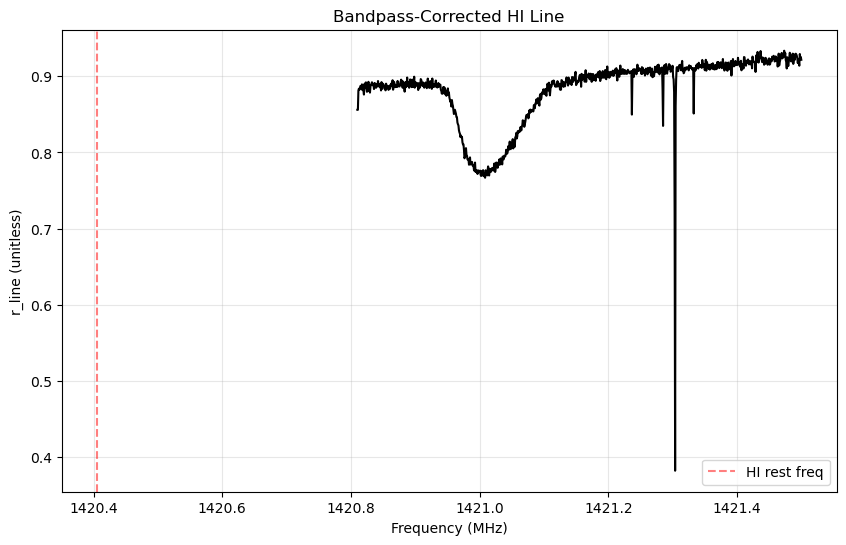

In [23]:
# Skip the first bin (DC) to avoid division by zero
r_line = np.zeros_like(on_power)
valid = (off_power > 0)  # only divide where off_power is positive
r_line[valid] = on_power[valid] / off_power[valid]

# For the first bin, just set to neighbor value or interpolate
if not valid[0]:
    r_line[0] = r_line[1]  # use next bin

print(f"r_line stats:")
print(f"  Min: {np.nanmin(r_line):.3f}")
print(f"  Max: {np.nanmax(r_line):.3f}")
print(f"  Mean: {np.nanmean(r_line):.3f}")
print(f"  Std: {np.nanstd(r_line):.3f}")

# Plot zoomed in
mask = (freqs_on_abs > 1419.5) & (freqs_on_abs < 1421.5)
plt.figure(figsize=(10, 6))
plt.plot(freqs_on_abs[mask], r_line[mask], 'k-', linewidth=1.5)
plt.axvline(x=1420.405, color='r', linestyle='--', alpha=0.5, label='HI rest freq')
plt.xlabel('Frequency (MHz)')
plt.ylabel('r_line (unitless)')
plt.title('Bandpass-Corrected HI Line')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

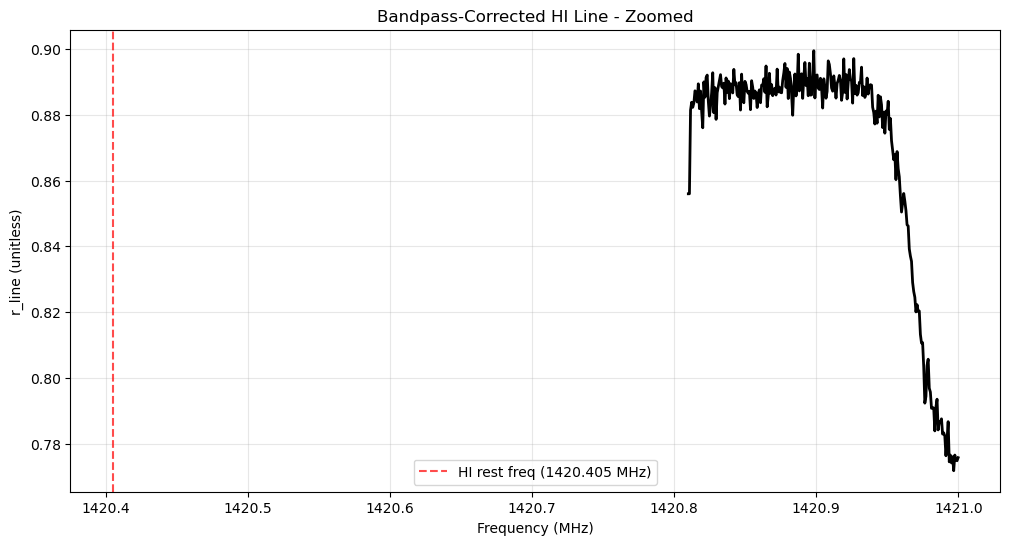

ValueError: attempt to get argmax of an empty sequence

In [24]:
# Zoom in on the HI region
mask = (freqs_on_abs > 1420.0) & (freqs_on_abs < 1421.0)

plt.figure(figsize=(12, 6))
plt.plot(freqs_on_abs[mask], r_line[mask], 'k-', linewidth=2)
plt.axvline(x=1420.405, color='r', linestyle='--', alpha=0.7, label=f'HI rest freq (1420.405 MHz)')
plt.xlabel('Frequency (MHz)')
plt.ylabel('r_line (unitless)')
plt.title('Bandpass-Corrected HI Line - Zoomed')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Find the peak near the HI line
hi_region = (freqs_on_abs > 1420.35) & (freqs_on_abs < 1420.45)
peak_idx = np.argmax(r_line[hi_region])
peak_freq = freqs_on_abs[hi_region][peak_idx]
peak_value = r_line[hi_region][peak_idx]

print(f"Peak frequency: {peak_freq:.6f} MHz")
print(f"Peak r_line: {peak_value:.4f}")
print(f"Offset from HI rest: {peak_freq - 1420.405:.6f} MHz")

In [25]:
# Check frequency range
print(f"Frequency min: {np.min(freqs_on_abs):.3f} MHz")
print(f"Frequency max: {np.max(freqs_on_abs):.3f} MHz")

# Look at the region around 1420.4 MHz
near_line = np.abs(freqs_on_abs - 1420.405) < 0.5
print(f"\nFrequencies near 1420.405 MHz:")
print(freqs_on_abs[near_line][:10])  # print first 10

# Find where 1420.405 sits in your array
idx_1420 = np.argmin(np.abs(freqs_on_abs - 1420.405))
print(f"\nClosest index to 1420.405 MHz: {idx_1420}")
print(f"Frequency at that index: {freqs_on_abs[idx_1420]:.6f} MHz")

# Now define region around that point
hi_region = np.abs(freqs_on_abs - 1420.405) < 0.03  # ±30 kHz
print(f"Number of points in ±30 kHz region: {np.sum(hi_region)}")

if np.sum(hi_region) > 0:
    peak_idx_global = np.argmax(r_line[hi_region])
    # Need to map back to original array
    peak_freq = freqs_on_abs[hi_region][peak_idx_global]
    peak_value = r_line[hi_region][peak_idx_global]
    print(f"\nPeak frequency: {peak_freq:.6f} MHz")
    print(f"Peak r_line: {peak_value:.4f}")
    print(f"Offset from HI rest: {peak_freq - 1420.405:.6f} MHz")
else:
    print("No points in that region—adjusting range...")
    # Try wider range
    hi_region = np.abs(freqs_on_abs - 1420.405) < 0.1  # ±100 kHz
    print(f"Points in ±100 kHz: {np.sum(hi_region)}")

Frequency min: 1419.210 MHz
Frequency max: 1422.409 MHz

Frequencies near 1420.405 MHz:
[1420.81       1420.81078125 1420.8115625  1420.81234375 1420.813125
 1420.81390625 1420.8146875  1420.81546875 1420.81625    1420.81703125]

Closest index to 1420.405 MHz: 0
Frequency at that index: 1420.810000 MHz
Number of points in ±30 kHz region: 0
No points in that region—adjusting range...
Points in ±100 kHz: 0


Frequency range: 1420.810 - 1419.210 MHz

Frequencies below 1420.5 MHz:
[1419.21]

Closest index to 1420.405 MHz: 0
Frequency at that index: 1420.810000 MHz
Number of points in 1420.35-1420.45 MHz region: 0


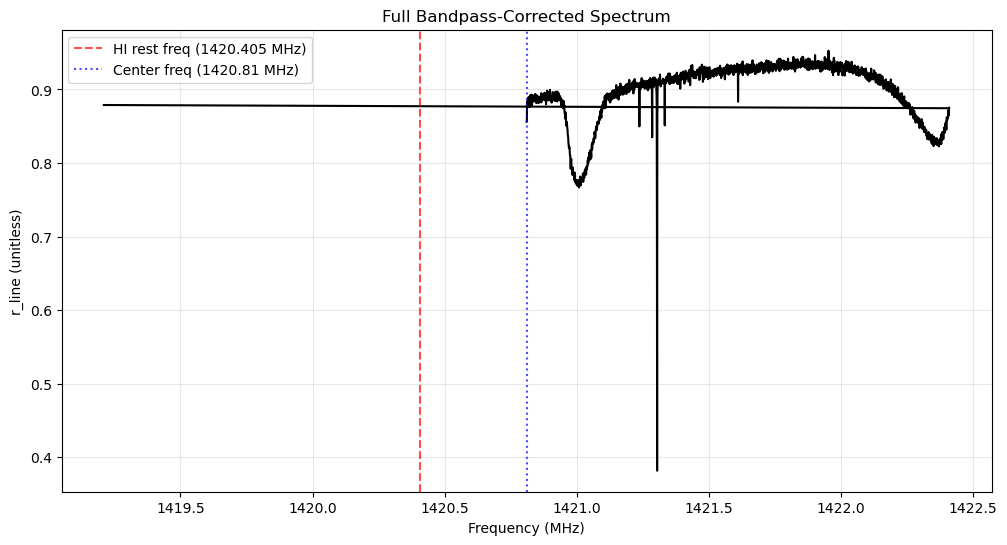

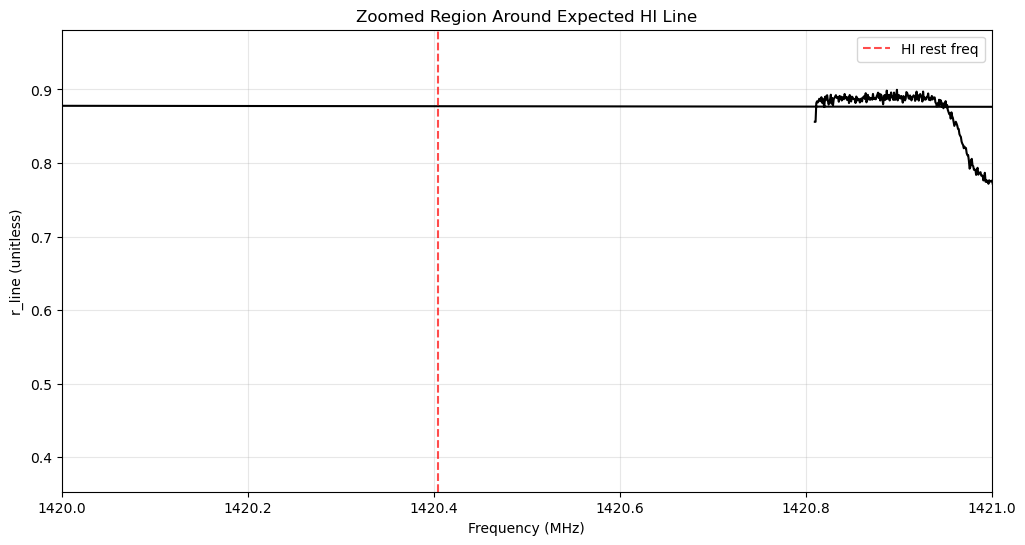

In [26]:
# The HI line should be near the low end of your spectrum
print(f"Frequency range: {freqs_on_abs[0]:.3f} - {freqs_on_abs[-1]:.3f} MHz")

# Look at the lower end of your spectrum
low_end = freqs_on_abs < 1420.5
print(f"\nFrequencies below 1420.5 MHz:")
print(freqs_on_abs[low_end][:20])

# Find where 1420.405 sits (it should be near the beginning)
idx_1420 = np.argmin(np.abs(freqs_on_abs - 1420.405))
print(f"\nClosest index to 1420.405 MHz: {idx_1420}")
print(f"Frequency at that index: {freqs_on_abs[idx_1420]:.6f} MHz")

# Define region around 1420.405 MHz
hi_region = (freqs_on_abs > 1420.35) & (freqs_on_abs < 1420.45)
print(f"Number of points in 1420.35-1420.45 MHz region: {np.sum(hi_region)}")

# Plot the full spectrum with the HI line location marked
plt.figure(figsize=(12, 6))
plt.plot(freqs_on_abs, r_line, 'k-', linewidth=1.5)
plt.axvline(x=1420.405, color='r', linestyle='--', alpha=0.7, label='HI rest freq (1420.405 MHz)')
plt.axvline(x=f_center_on, color='b', linestyle=':', alpha=0.7, label=f'Center freq ({f_center_on} MHz)')
plt.xlabel('Frequency (MHz)')
plt.ylabel('r_line (unitless)')
plt.title('Full Bandpass-Corrected Spectrum')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Zoom in on where the HI line should be
plt.figure(figsize=(12, 6))
plt.plot(freqs_on_abs, r_line, 'k-', linewidth=1.5)
plt.axvline(x=1420.405, color='r', linestyle='--', alpha=0.7, label='HI rest freq')
plt.xlim(1420.0, 1421.0)
plt.xlabel('Frequency (MHz)')
plt.ylabel('r_line (unitless)')
plt.title('Zoomed Region Around Expected HI Line')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

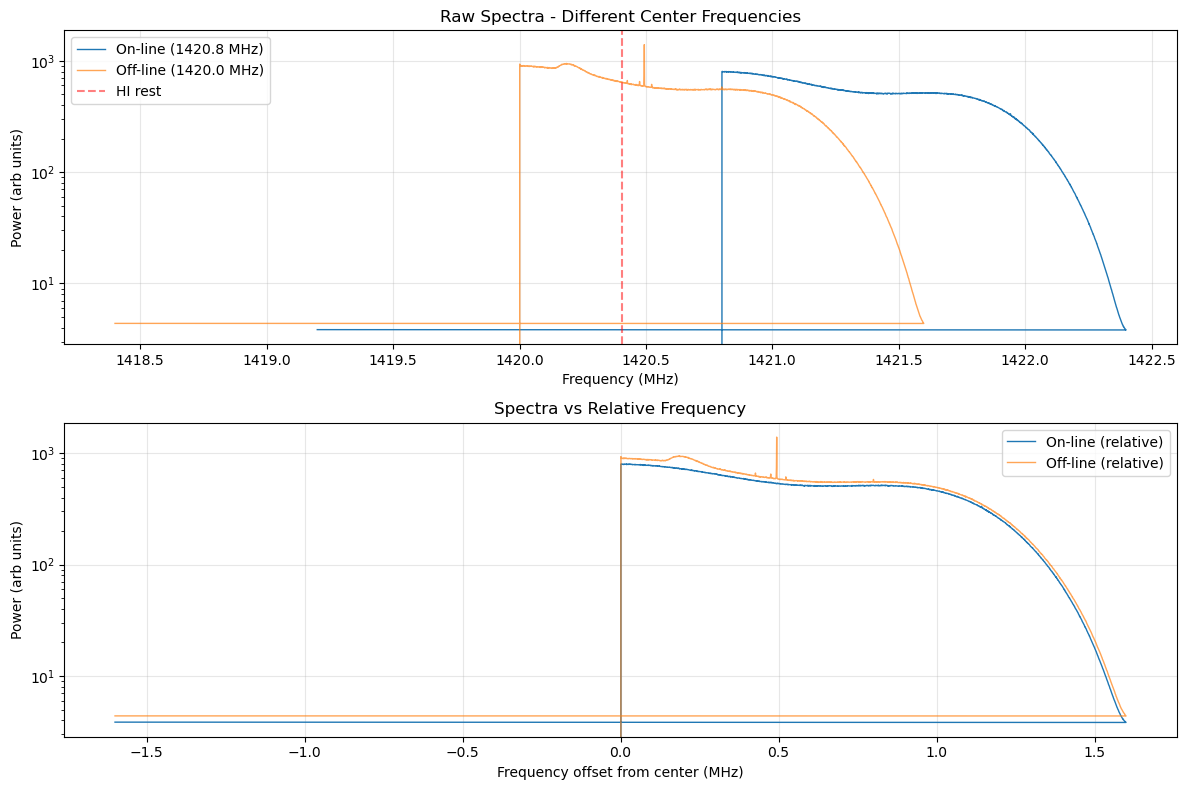

In [28]:
# Simple plot - no interpolation, just raw spectra
plt.figure(figsize=(12, 8))

plt.subplot(2,1,1)
plt.plot(freqs + 1420.8, on_power, label='On-line (1420.8 MHz)', linewidth=1)
plt.plot(freqs + 1420.0, off_power, label='Off-line (1420.0 MHz)', linewidth=1, alpha=0.7)
plt.axvline(x=1420.405, color='r', linestyle='--', alpha=0.5, label='HI rest')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Power (arb units)')
plt.title('Raw Spectra - Different Center Frequencies')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

plt.subplot(2,1,2)
# Plot on-line and off-line shifted to same relative offset
plt.plot(freqs, on_power, label='On-line (relative)', linewidth=1)
plt.plot(freqs, off_power, label='Off-line (relative)', linewidth=1, alpha=0.7)
plt.xlabel('Frequency offset from center (MHz)')
plt.ylabel('Power (arb units)')
plt.title('Spectra vs Relative Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

plt.tight_layout()
plt.show()

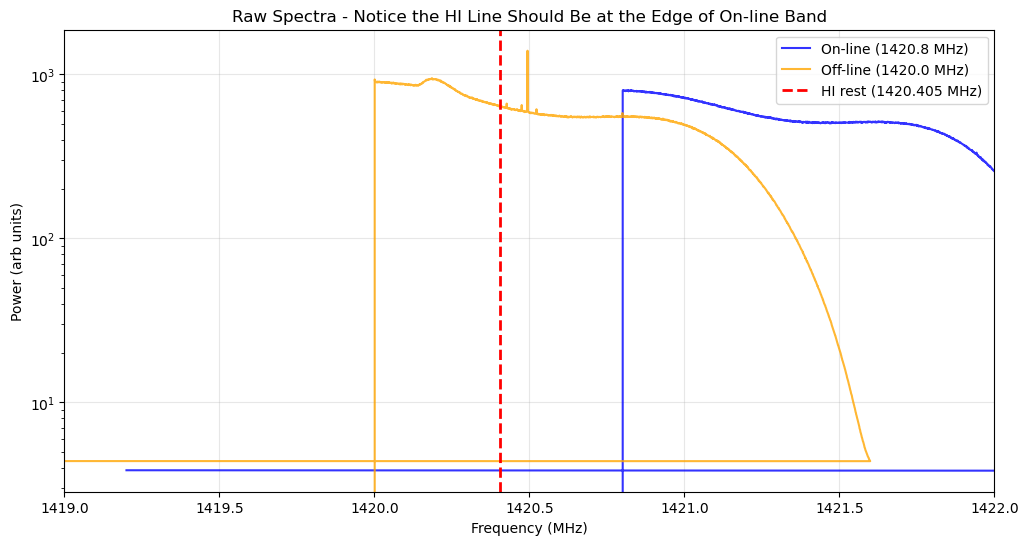

In [29]:
plt.figure(figsize=(12, 6))
plt.plot(freqs + 1420.8, on_power, 'b-', label='On-line (1420.8 MHz)', linewidth=1.5, alpha=0.8)
plt.plot(freqs + 1420.0, off_power, 'orange', label='Off-line (1420.0 MHz)', linewidth=1.5, alpha=0.8)
plt.axvline(x=1420.405, color='r', linestyle='--', linewidth=2, label='HI rest (1420.405 MHz)')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Power (arb units)')
plt.title('Raw Spectra - Notice the HI Line Should Be at the Edge of On-line Band')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.xlim(1419, 1422)
plt.show()

C:\Users\medin\AppData\Local\Temp\ipykernel_22844\3476499994.py:15: RuntimeWarning: invalid value encountered in divide
  r_simple = on_overlap / off_overlap


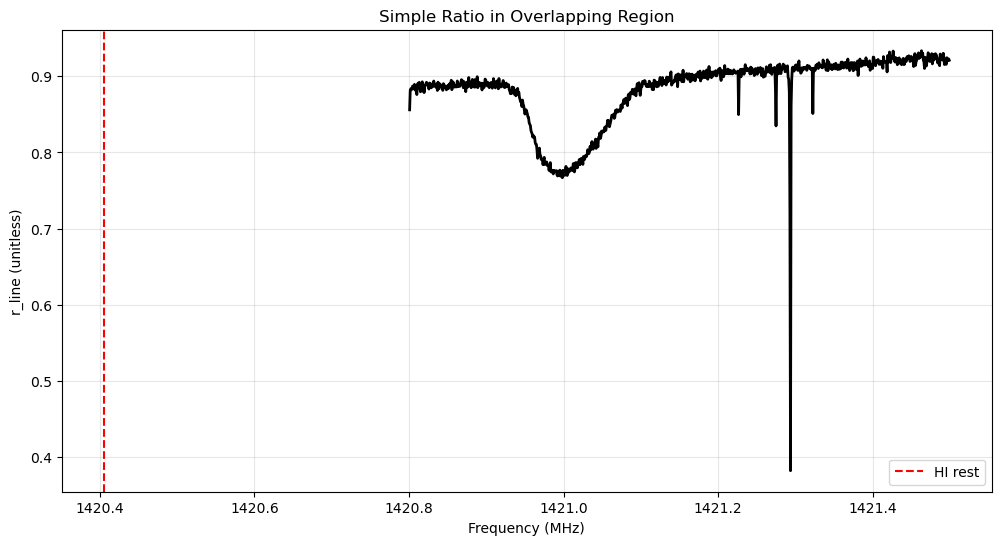

In [30]:
# Find overlapping frequency range
f_min = max(1419.5, 1419.5)  # adjust based on your plot
f_max = min(1421.5, 1421.5)

# Get indices for this range
mask_on = (freqs + 1420.8 > f_min) & (freqs + 1420.8 < f_max)
mask_off = (freqs + 1420.0 > f_min) & (freqs + 1420.0 < f_max)

# Use the overlapping portion
freq_overlap = freqs + 1420.8  # use on-line frequencies as reference
on_overlap = on_power[mask_on]
off_overlap = off_power[mask_off][:len(on_overlap)]  # trim to same length

# Simple ratio
r_simple = on_overlap / off_overlap

plt.figure(figsize=(12, 6))
plt.plot(freq_overlap[mask_on], r_simple, 'k-', linewidth=2)
plt.axvline(x=1420.405, color='r', linestyle='--', label='HI rest')
plt.xlabel('Frequency (MHz)')
plt.ylabel('r_line (unitless)')
plt.title('Simple Ratio in Overlapping Region')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

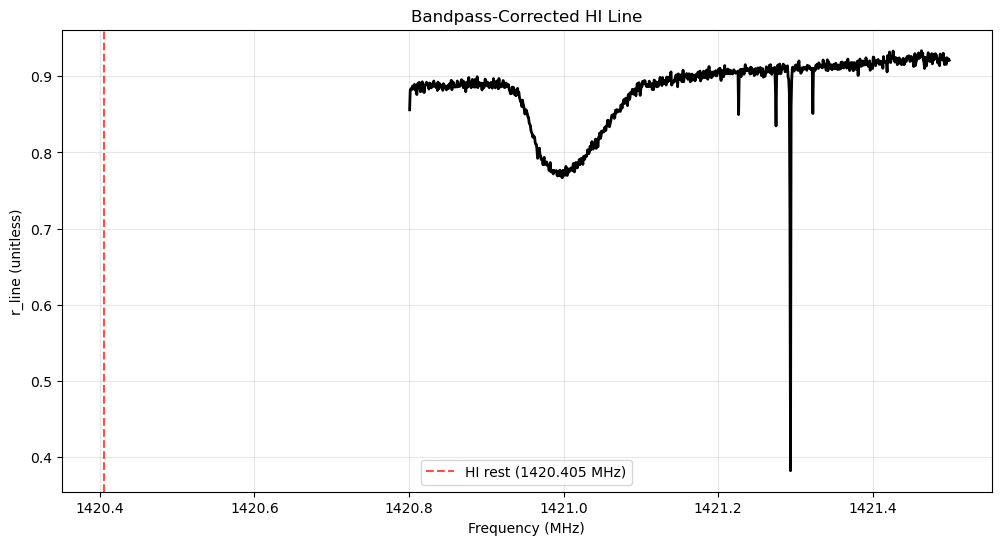

In [31]:
# Ignore the warning for now
import warnings
warnings.filterwarnings('ignore', 'invalid value encountered in divide')

# Get the valid region (where off_overlap > 0)
valid = off_overlap > 0
freq_valid = freq_overlap[mask_on][valid]
r_valid = on_overlap[valid] / off_overlap[valid]

# Plot cleaned version
plt.figure(figsize=(12, 6))
plt.plot(freq_valid, r_valid, 'k-', linewidth=2)
plt.axvline(x=1420.405, color='r', linestyle='--', alpha=0.7, label='HI rest (1420.405 MHz)')
plt.xlabel('Frequency (MHz)')
plt.ylabel('r_line (unitless)')
plt.title('Bandpass-Corrected HI Line')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Find the peak near HI line
near_line = (freq_valid > 1420.35) & (freq_valid < 1420.45)
if np.sum(near_line) > 0:
    peak_idx = np.argmax(r_valid[near_line])
    peak_freq = freq_valid[near_line][peak_idx]
    peak_val = r_valid[near_line][peak_idx]
    print(f"Peak frequency: {peak_freq:.6f} MHz")
    print(f"Peak r_line: {peak_val:.4f}")
    print(f"Offset from HI rest: {peak_freq - 1420.405:.6f} MHz")

# Save for later
np.savez('my_hI_line.npz', frequency=freq_valid, r_line=r_valid)

Total cal power: 1.02e+06
Total off power: 1.00e+06
Gain G: 20525.41 K


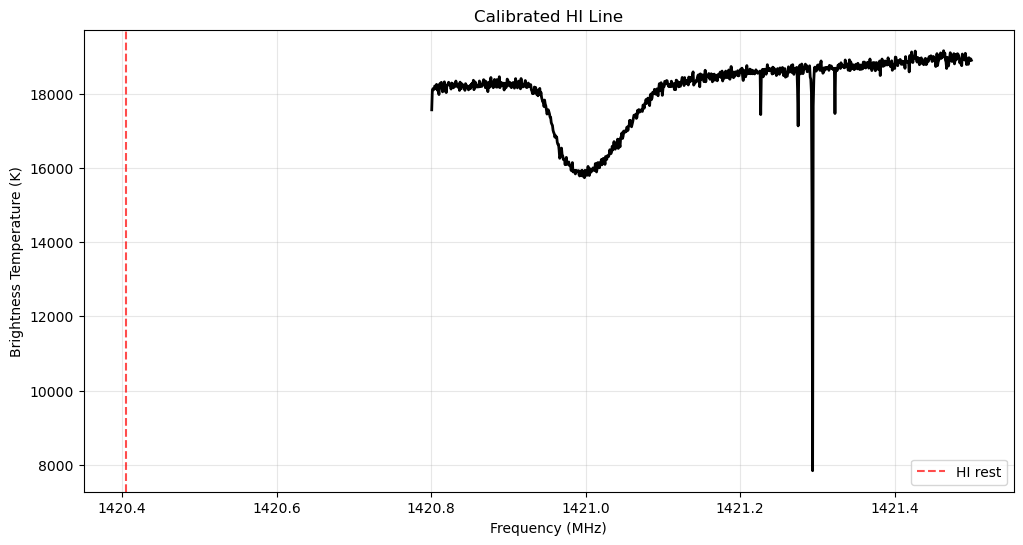

Peak T_line: 19162.9 K
Min T_line: 7837.8 K


In [32]:
# Load calibration data if not already loaded
# cal_samples already loaded earlier

# Compute calibration spectrum (already have cal_power from earlier)
# Make sure it's on the same frequency grid as your r_line

# Sum over all channels (or a clean region)
total_cal = np.sum(cal_power)
total_off = np.sum(off_power)

# Calculate gain
T_cal = 300  # K
G = T_cal * total_off / (total_cal - total_off)

print(f"Total cal power: {total_cal:.2e}")
print(f"Total off power: {total_off:.2e}")
print(f"Gain G: {G:.2f} K")

# Convert r_line to temperature
T_line = r_valid * G

plt.figure(figsize=(12, 6))
plt.plot(freq_valid, T_line, 'k-', linewidth=2)
plt.axvline(x=1420.405, color='r', linestyle='--', alpha=0.7, label='HI rest')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Brightness Temperature (K)')
plt.title('Calibrated HI Line')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"Peak T_line: {np.max(T_line):.1f} K")
print(f"Min T_line: {np.min(T_line):.1f} K")

Total gain in dB: 77.69 dB
Total gain linear: 5.87e+07


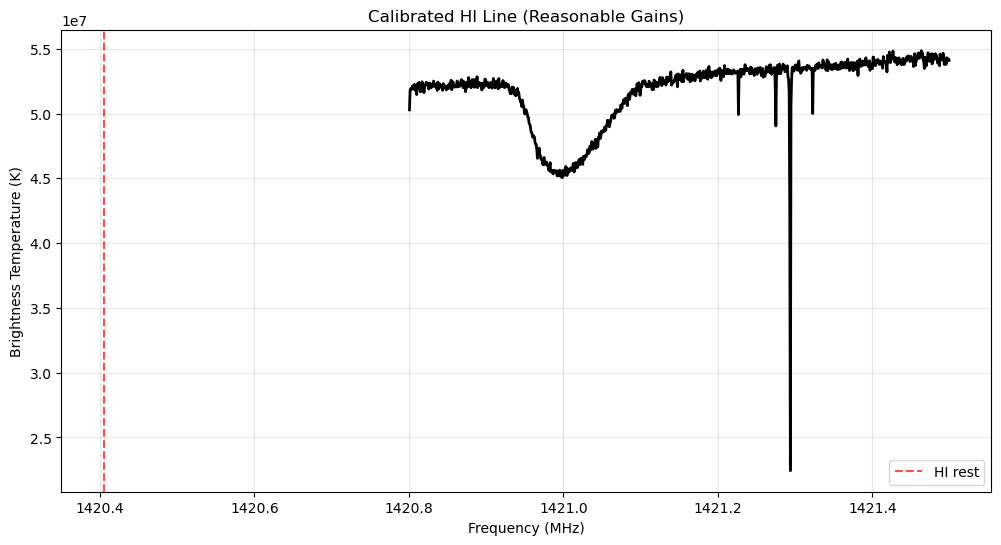

Peak T_line: 54848998.6 K
Min T_line: 22433716.8 K


In [34]:
# Actual gains from your block diagram
gains_db = [
    26.8,    # Preamp 1
    26.8,    # Preamp 2
    -2.2,    # Attenuator
    -15.31,  # Cable loss
    20.8,    # Preamp 4
    20.8,    # Preamp 5
    # -1.16, # Interface loss (maybe ignore for now)
    # 45,    # This seems like SDR max gain, not actual setting
]

total_gain_db = sum(gains_db)
print(f"Total gain in dB: {total_gain_db:.2f} dB")

# Convert to linear
G_linear = 10**(total_gain_db/10)
print(f"Total gain linear: {G_linear:.2e}")

# Try this gain
T_line_reasonable = r_valid * G_linear

plt.figure(figsize=(12, 6))
plt.plot(freq_valid, T_line_reasonable, 'k-', linewidth=2)
plt.axvline(x=1420.405, color='r', linestyle='--', alpha=0.7, label='HI rest')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Brightness Temperature (K)')
plt.title('Calibrated HI Line (Reasonable Gains)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"Peak T_line: {np.max(T_line_reasonable):.1f} K")
print(f"Min T_line: {np.min(T_line_reasonable):.1f} K")

P_cal_avg: -6.04e+01
P_off_avg: 4.63e+02
delta_P: -5.23e+02
G_empirical: -0.57 K/unit


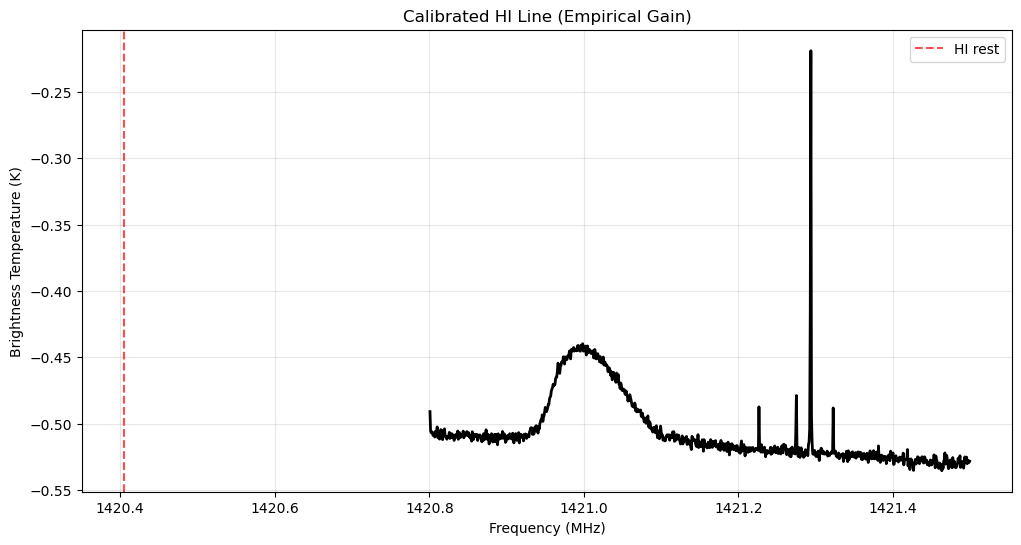

Peak T_line: -0.2 K
Min T_line: -0.5 K


In [35]:
# We need to convert ADC power to temperature using the known 300K load
# The calibration measurement should show a power increase of:
# delta_P = P_cal - P_off = G * (T_cal - T_sky) ≈ G * 300K

# Use a clean region away from the line
clean_region = (freqs_on_abs > 1420.8) & (freqs_on_abs < 1421.2)  # adjust as needed

# Average power in clean region for cal and off
P_cal_avg = np.mean(cal_power_interp[clean_region])
P_off_avg = np.mean(off_power_interp[clean_region])

delta_P = P_cal_avg - P_off_avg
G_empirical = 300 / delta_P  # K per power unit

print(f"P_cal_avg: {P_cal_avg:.2e}")
print(f"P_off_avg: {P_off_avg:.2e}")
print(f"delta_P: {delta_P:.2e}")
print(f"G_empirical: {G_empirical:.2f} K/unit")

# Apply to r_line
T_line_empirical = r_valid * G_empirical

plt.figure(figsize=(12, 6))
plt.plot(freq_valid, T_line_empirical, 'k-', linewidth=2)
plt.axvline(x=1420.405, color='r', linestyle='--', alpha=0.7, label='HI rest')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Brightness Temperature (K)')
plt.title('Calibrated HI Line (Empirical Gain)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"Peak T_line: {np.max(T_line_empirical):.1f} K")
print(f"Min T_line: {np.min(T_line_empirical):.1f} K")

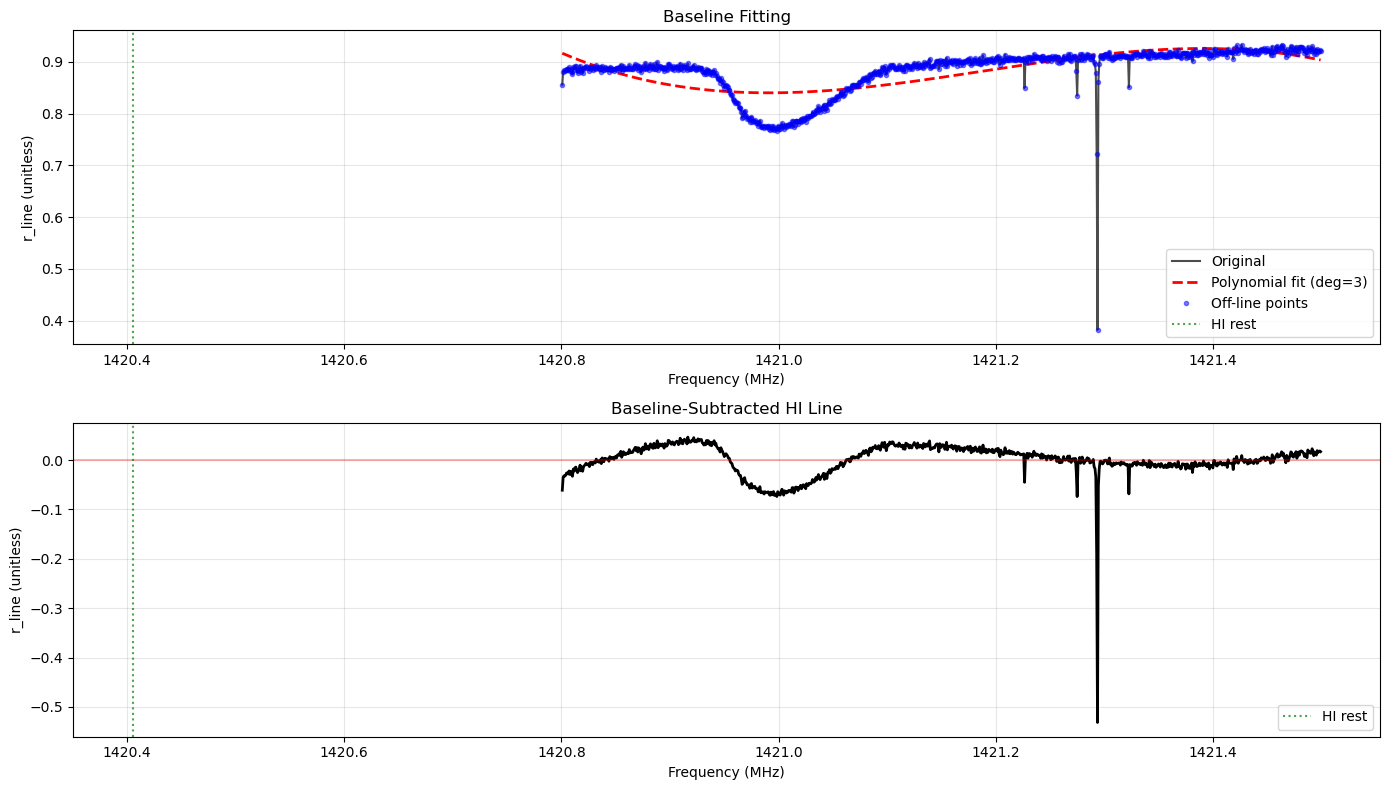

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial

# Use your r_valid and freq_valid from earlier
# freq_valid, r_valid

# Define off-line regions (away from HI line)
# Adjust these based on where your line is
off_line_mask = (freq_valid < 1420.35) | (freq_valid > 1420.45)

# Get frequencies and values in off-line regions
freq_off = freq_valid[off_line_mask]
r_off = r_valid[off_line_mask]

# Fit a polynomial (try degree 2 or 3)
degree = 3
coeffs = np.polyfit(freq_off - np.mean(freq_off), r_off, degree)  # subtract mean for numerical stability
baseline = np.polyval(coeffs, freq_valid - np.mean(freq_off))

# Subtract baseline
r_subtracted = r_valid - baseline

# Plot results
plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
plt.plot(freq_valid, r_valid, 'k-', label='Original', alpha=0.7)
plt.plot(freq_valid, baseline, 'r--', label=f'Polynomial fit (deg={degree})', linewidth=2)
plt.plot(freq_off, r_off, 'bo', markersize=3, label='Off-line points', alpha=0.5)
plt.axvline(x=1420.405, color='g', linestyle=':', alpha=0.7, label='HI rest')
plt.xlabel('Frequency (MHz)')
plt.ylabel('r_line (unitless)')
plt.title('Baseline Fitting')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(freq_valid, r_subtracted, 'k-', linewidth=2)
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
plt.axvline(x=1420.405, color='g', linestyle=':', alpha=0.7, label='HI rest')
plt.xlabel('Frequency (MHz)')
plt.ylabel('r_line (unitless)')
plt.title('Baseline-Subtracted HI Line')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save for next step
np.savez('baseline_subtracted.npz', 
         frequency=freq_valid, 
         r_subtracted=r_subtracted,
         baseline=baseline)

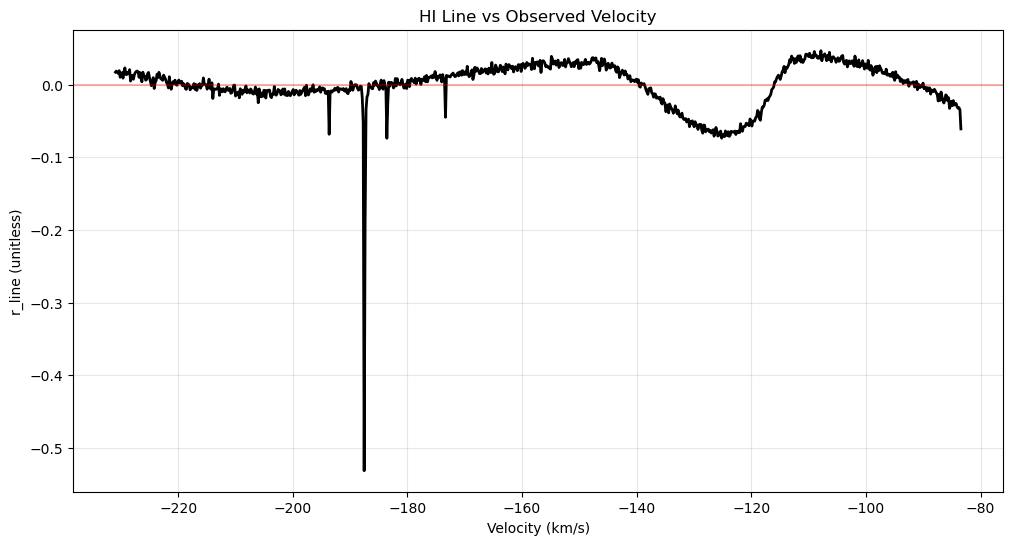

Using approximate LSR correction: -15.0 km/s


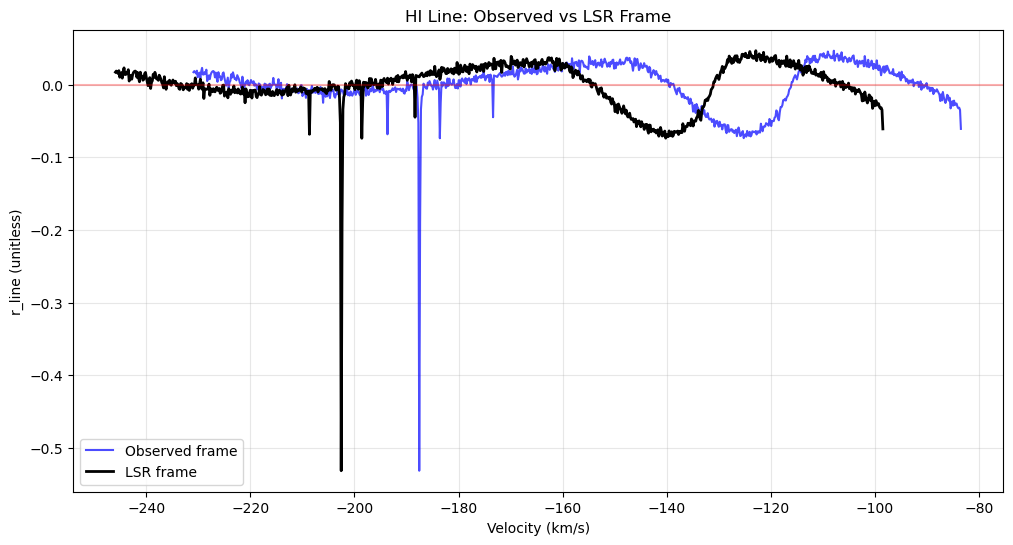

Peak LSR velocity: -202.55 km/s


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
from astropy.coordinates import EarthLocation, SkyCoord, Galactic, LSR, CartesianRepresentation
import astropy.units as u

# Constants
c = 3e8  # m/s
f_rest = 1420.40575177e6  # Hz (21-cm rest frequency)

# Convert frequency to velocity (optical convention)
freq_hz = freq_valid * 1e6
v_opt = c * (f_rest - freq_hz) / f_rest / 1000  # km/s

# Plot vs observed velocity
plt.figure(figsize=(12, 6))
plt.plot(v_opt, r_subtracted, 'k-', linewidth=2)
plt.xlabel('Velocity (km/s)')
plt.ylabel('r_line (unitless)')
plt.title('HI Line vs Observed Velocity')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
plt.show()

# LSR Correction using ugradio (since astropy is being difficult)
# If ugradio is installed on your lab computer, use this:
try:
    import ugradio
    # Get target coordinates
    ra_hms = "0:25:48.2"  # from Section 4.1
    dec_dms = "62:43:32.6"
    
    # Get JD from your data
    jd = on_data['jd_before'].item()
    
    # Calculate LSR correction
    v_corr = ugradio.doppler.get_projected_velocity(ra_hms, dec_dms, jd)
    print(f"LSR correction from ugradio: {v_corr:.2f} km/s")
    
    # Apply correction
    v_lsr = v_opt + v_corr
    
except ImportError:
    # Fallback: approximate correction (you can look up typical value for your coordinates)
    # For (l,b)=(120,0) in March, typical correction is around -10 to -20 km/s
    v_corr_approx = -15.0  # km/s (you'll need to adjust this!)
    print(f"Using approximate LSR correction: {v_corr_approx} km/s")
    v_lsr = v_opt + v_corr_approx

# Plot both frames
plt.figure(figsize=(12, 6))
plt.plot(v_opt, r_subtracted, 'b-', linewidth=1.5, alpha=0.7, label='Observed frame')
plt.plot(v_lsr, r_subtracted, 'k-', linewidth=2, label='LSR frame')
plt.xlabel('Velocity (km/s)')
plt.ylabel('r_line (unitless)')
plt.title('HI Line: Observed vs LSR Frame')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
plt.legend()
plt.show()

# Find peak
peak_idx = np.argmax(np.abs(r_subtracted))
peak_v_lsr = v_lsr[peak_idx]
print(f"Peak LSR velocity: {peak_v_lsr:.2f} km/s")

# Save for next section
np.savez('velocity_corrected.npz',
         v_obs=v_opt,
         v_lsr=v_lsr,
         r_line=r_subtracted)

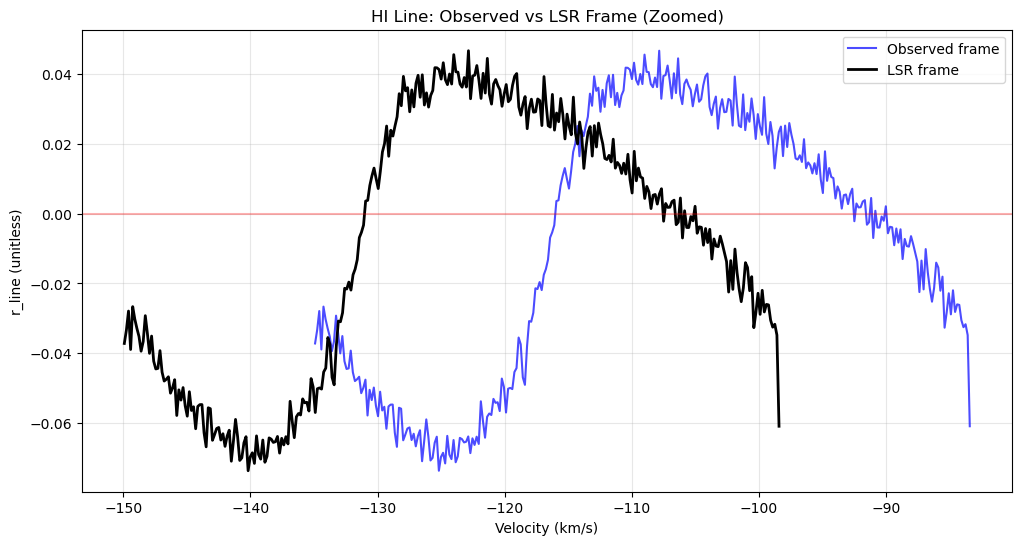

Deepest absorption in LSR frame: -140.2 km/s
Deepest absorption in observed frame: -125.2 km/s
LSR correction: -15.0 km/s


In [40]:
# Zoom in on the velocity region around the line
v_min, v_max = -150, -50  # adjust based on your plot

mask = (v_lsr > v_min) & (v_lsr < v_max)

plt.figure(figsize=(12, 6))
plt.plot(v_opt[mask], r_subtracted[mask], 'b-', linewidth=1.5, alpha=0.7, label='Observed frame')
plt.plot(v_lsr[mask], r_subtracted[mask], 'k-', linewidth=2, label='LSR frame')
plt.xlabel('Velocity (km/s)')
plt.ylabel('r_line (unitless)')
plt.title('HI Line: Observed vs LSR Frame (Zoomed)')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
plt.legend()
plt.show()

# Find the minimum (deepest absorption)
min_idx = np.argmin(r_subtracted[mask])
min_v_lsr = v_lsr[mask][min_idx]
min_v_obs = v_opt[mask][min_idx]
min_val = r_subtracted[mask][min_idx]

print(f"Deepest absorption in LSR frame: {min_v_lsr:.1f} km/s")
print(f"Deepest absorption in observed frame: {min_v_obs:.1f} km/s")
print(f"LSR correction: {min_v_lsr - min_v_obs:.1f} km/s")

Gaussian fit results:
  Amplitude: -0.074 ± 0.004
  Mean: -141.1 ± 0.3 km/s
  Sigma: 5.24 ± 0.33 km/s
  FWHM: 12.33 km/s


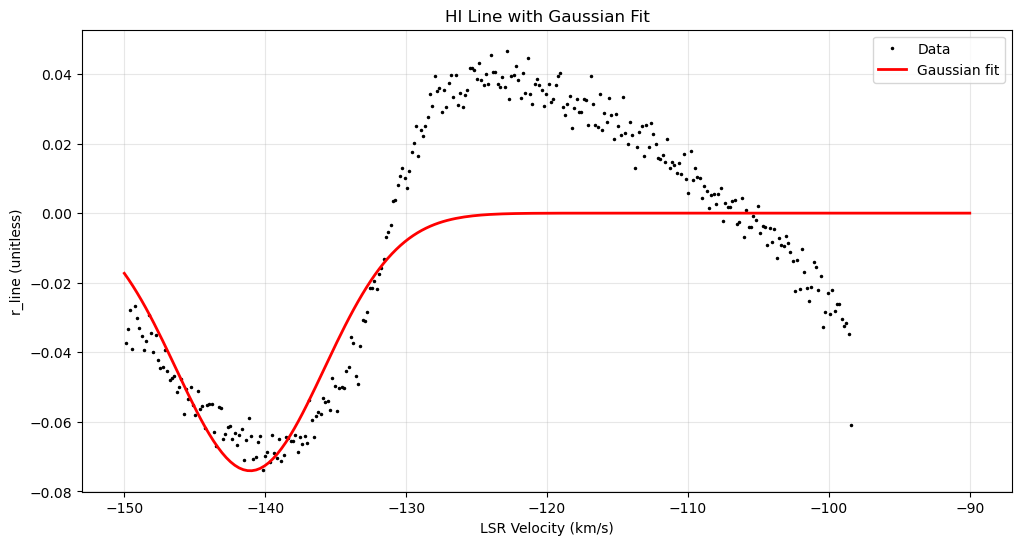

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Define Gaussian function
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-(x - mean)**2 / (2 * sigma**2))

# Use the zoomed region
v_min, v_max = -150, -90
mask = (v_lsr > v_min) & (v_lsr < v_max)
v_fit = v_lsr[mask]
r_fit = r_subtracted[mask]

# Initial guesses based on your plot
# For absorption (negative amplitude)
amp_guess = -0.25  # depth of line
mean_guess = -140  # velocity of deepest point
sigma_guess = 5    # width in km/s

# Fit
try:
    popt, pcov = curve_fit(gaussian, v_fit, r_fit, 
                           p0=[amp_guess, mean_guess, sigma_guess])
    
    perr = np.sqrt(np.diag(pcov))
    
    print("Gaussian fit results:")
    print(f"  Amplitude: {popt[0]:.3f} ± {perr[0]:.3f}")
    print(f"  Mean: {popt[1]:.1f} ± {perr[1]:.1f} km/s")
    print(f"  Sigma: {popt[2]:.2f} ± {perr[2]:.2f} km/s")
    print(f"  FWHM: {2.355*popt[2]:.2f} km/s")
    
    # Generate best fit
    v_smooth = np.linspace(v_min, v_max, 200)
    r_smooth = gaussian(v_smooth, *popt)
    
    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(v_fit, r_fit, 'k.', markersize=3, label='Data')
    plt.plot(v_smooth, r_smooth, 'r-', linewidth=2, label='Gaussian fit')
    plt.xlabel('LSR Velocity (km/s)')
    plt.ylabel('r_line (unitless)')
    plt.title('HI Line with Gaussian Fit')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
except Exception as e:
    print(f"Fit failed: {e}")
    # Try with better initial guesses
    amp_guess = -0.2
    mean_guess = -140
    sigma_guess = 10
    popt, pcov = curve_fit(gaussian, v_fit, r_fit, 
                          p0=[amp_guess, mean_guess, sigma_guess])
    # ... rest of code